# Cross-check against the independent comparison model

The project contains two separately written implementations of the same idea. The main model (`src/`) was
used for the main experiments (300 people, 10% vaccinated). The comparison model (`comparison_model/`) was
written independently, with different code and different settings (100 people, 20% vaccinated, 4 contacts per
person, 100 repetitions, only no / random / degree-targeted vaccination).

This notebook does two things:

1. **Agreement.** Run the main model with the comparison model's settings and check that the two
   implementations give the same answers. If they do, differences between their headline results must come
   from the settings and not from a bug in either implementation.
2. **Why do the two models disagree on random networks?** In the main experiments, targeting the best-connected
   people was no better than random vaccination on a random network, while the comparison model found a large
   advantage. We test whether the vaccination coverage (10% against 20%) explains this.

In [1]:
import os
os.environ["TQDM_DISABLE"] = "1"   # no progress bars in the notebook output

import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.experiment import run_sweep

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
COLOURS = {"none": "#8a8985", "random": "#2a78d6", "degree": "#eb6834"}

## 1. Run the main model with the comparison model's settings

In [2]:
BETAS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
main = run_sweep(["random", "small_world", "scale_free"], ["none", "random", "degree"], BETAS,
                 n=100, avg_degree=4, gamma=0.1, budget=0.2, n_replications=100)
main["epidemic_size"] = main["final_size"] * 100          # number of people infected, as in the comparison model
main_mean = main.groupby(["topology", "strategy", "beta"]).epidemic_size.mean().reset_index()

partner = pd.read_csv("../comparison_model/results/beta_sweep_results.csv")
partner = partner.replace({"No Vaccination": "none", "20% Random": "random", "20% Targeted": "degree"})
partner = partner.rename(columns={"network": "topology"})

both = main_mean.merge(partner[["topology", "strategy", "beta", "epidemic_size"]],
                       on=["topology", "strategy", "beta"], suffixes=("_main", "_comparison"))
corr = np.corrcoef(both.epidemic_size_main, both.epidemic_size_comparison)[0, 1]
mad = (both.epidemic_size_main - both.epidemic_size_comparison).abs().mean()
print(f"{len(both)} parameter combinations compared")
print(f"correlation = {corr:.3f}, mean absolute difference = {mad:.1f} people out of 100")

54 parameter combinations compared
correlation = 0.995, mean absolute difference = 2.0 people out of 100


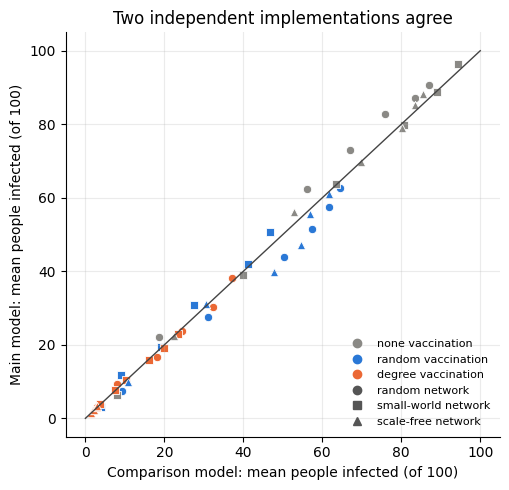

In [3]:
fig, ax = plt.subplots(figsize=(5.2, 5))
markers = {"random": "o", "small_world": "s", "scale_free": "^"}
for topo, mk in markers.items():
    for strat, col in COLOURS.items():
        r = both[(both.topology == topo) & (both.strategy == strat)]
        ax.scatter(r.epidemic_size_comparison, r.epidemic_size_main, marker=mk, color=col, s=36,
                   edgecolor="white", linewidth=0.6)
ax.plot([0, 100], [0, 100], color="#444", linewidth=1)
ax.set_xlabel("Comparison model: mean people infected (of 100)")
ax.set_ylabel("Main model: mean people infected (of 100)")
ax.set_title("Two independent implementations agree")
# legend: colour = strategy, marker = network
from matplotlib.lines import Line2D
handles = [Line2D([], [], marker="o", linestyle="", color=c, label=s + " vaccination") for s, c in COLOURS.items()]
handles += [Line2D([], [], marker=m, linestyle="", color="#555", label=t.replace("_", "-") + " network") for t, m in markers.items()]
ax.legend(handles=handles, frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig("../results/cross_check_agreement.png", dpi=150)
plt.show()

**Reading the chart.** Every point is one combination of network, strategy and beta. The points lie on the
diagonal: the two implementations agree to within a few people out of 100 (see the correlation and mean
absolute difference above). This is strong evidence that both implementations are correct, because they were
written independently, and it means that any differences in the headline findings come from the settings
(population, coverage, number of contacts) and not from the code.

## 2. Does the vaccination coverage explain the disagreement on random networks?

We keep the main model's network (random, 300 people, 6 contacts) and change only the vaccination coverage.

In [4]:
rows = []
for budget in [0.05, 0.10, 0.20, 0.30]:
    d = run_sweep(["random"], ["random", "degree"], [0.10, 0.20], n=300, avg_degree=6, gamma=0.1,
                  budget=budget, n_replications=40)
    d["budget"] = budget
    rows.append(d)
cov = pd.concat(rows)
cov.to_csv("../results/coverage_sweep_random_network.csv", index=False)
table = cov.groupby(["beta", "budget", "strategy"]).final_size.mean().unstack().round(3)
table

strategy     degree  random
beta budget                
0.1  0.05     0.776   0.760
     0.10     0.658   0.691
     0.20     0.443   0.526
     0.30     0.102   0.403
0.2  0.05     0.860   0.842
     0.10     0.805   0.791
     0.20     0.640   0.676
     0.30     0.366   0.546

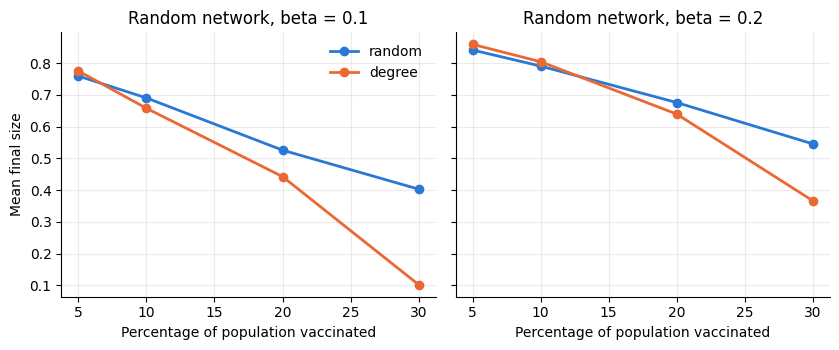

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.6), sharey=True)
for ax, beta in zip(axes, [0.10, 0.20]):
    for strat in ["random", "degree"]:
        r = cov[(cov.beta == beta) & (cov.strategy == strat)].groupby("budget").final_size.mean()
        ax.plot(r.index * 100, r.values, marker="o", linewidth=2, color=COLOURS[strat], label=strat)
    ax.set_title(f"Random network, beta = {beta}")
    ax.set_xlabel("Percentage of population vaccinated")
axes[0].set_ylabel("Mean final size")
axes[0].legend(frameon=False)
fig.tight_layout()
fig.savefig("../results/cross_check_coverage.png", dpi=150)
plt.show()

**Reading the chart.** On a random network, vaccinating by degree is about as good as vaccinating at random
when only 5% to 10% of people are vaccinated, but the gap opens up as coverage grows: at 20% coverage
targeting shows an advantage (at beta = 0.10, final size about 0.44 against 0.53) and at 30% coverage it is far
better (about 0.10 against 0.40). Removing the highest-degree people only matters once enough of them are removed to take a large
share of all connections out of the network.

The comparison model used 20% coverage, and also a smaller and sparser network (100 people, 4 contacts per person),
where targeting is even more effective: running the main model with those settings gives about 9 against 28 people
infected out of 100 at beta = 0.10 (degree against random). So the two models do not contradict each other. They were
run in different regimes, and the main experiments' finding that targeting does not beat random vaccination on a
random network holds for low coverage (about 10%) on the larger network only. We tested coverage directly; the
effect of the network size and density was only checked through the agreement run in section 1.

**Conclusion of the cross-check.** The two implementations agree numerically, and the apparent disagreement is explained by the
different settings, with vaccination coverage as the main factor we tested. This adds a limitation to our main conclusions,
which are for a 10% budget.